# Diplomatura en Python para la Ciencia de Datos y Machine Learning
# Guía de Estudio — Unidad 3
## Funciones de Activación, Funciones de Pérdida y Perceptrón Multicapa (MLP)

> **Para qué sirve este cuaderno:** es el material de estudio que acompaña al **Trabajo Práctico 3**.
> Todo lo que aparece en el TP está explicado acá: qué es, por qué se hace, cómo se calcula y qué pasaría si no lo hiciéramos.
> Las celdas de código son ejemplos chicos y rápidos: se pueden ejecutar y modificar para ver qué cambia.

---

### Mapa de la unidad

| # | Tema | Pregunta que responde |
|---|------|----------------------|
| 1 | Del Perceptrón Simple al MLP | ¿Por qué necesitamos más de una neurona? |
| 2 | Arquitectura del MLP | ¿Cómo está armada la red y cuántos parámetros tiene? |
| 3 | Funciones de activación | ¿Por qué hace falta "romper la linealidad"? |
| 4 | Funciones de pérdida | ¿Cómo mide la red cuánto se equivocó? |
| 5 | El entrenamiento | ¿Cómo aprende? (forward, loss, backpropagation, SGD) |
| 6 | Hiperparámetros | ¿Qué decidimos nosotros y qué aprende el modelo? |
| 7 | Preprocesamiento | ¿Por qué normalizar y aplanar? |
| 8 | Evaluación | ¿Cómo sé si funciona? (accuracy, precision, recall, F1) |
| 9 | Sobreajuste y regularización | ¿Por qué anda bien en train y mal en test? |
| 10 | Glosario + chuleta + autoevaluación | Repaso final |


---
# 1. Del Perceptrón Simple al MLP

## 1.1 Repaso: la neurona artificial

Una **neurona artificial** (perceptrón) hace siempre lo mismo, en dos pasos:

**Paso 1 — Combinación lineal (la parte "aburrida"):**

$$z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = \mathbf{W}\cdot\mathbf{x} + b$$

**Paso 2 — Función de activación (la parte "interesante"):**

$$\hat{y} = g(z)$$

| Componente | Símbolo | Qué es | ¿Quién lo define? |
|---|---|---|---|
| Entradas | $x$ | Los datos (en MNIST, los 784 píxeles) | El dataset |
| Pesos | $w$ | Cuánta importancia tiene cada entrada | **Los aprende la red** |
| Sesgo / Bias | $b$ | Corrimiento: permite que la frontera no pase por el origen | **Lo aprende la red** |
| Activación | $g$ | Transformación no lineal de $z$ | Nosotros (hiperparámetro) |

> 💡 **Analogía del bias:** si $z = w_1x_1 + w_2x_2$ (sin $b$), la recta de decisión está **obligada** a pasar por el punto (0,0).
> El bias le permite "moverse" y ubicarse donde realmente separa los datos. Es la ordenada al origen de la recta $y = mx + b$.

## 1.2 La limitación del Perceptrón Simple

Una sola neurona traza **una sola recta** (un hiperplano). Por lo tanto **solo resuelve problemas linealmente separables**.

- ✅ AND, OR, NAND → se pueden separar con una recta.
- ❌ **XOR** → **no existe** ninguna recta que los separe. Es el contraejemplo clásico.

```
        AND (separable)              XOR (NO separable)
    x2                           x2
    1 | o       *                1 | *       o
      |    /                       |
    0 | o /     o                0 | o       *
      +-----------  x1             +-----------  x1
        0       1                    0       1
      (una recta alcanza)         (ninguna recta alcanza)
```

**La solución es el MLP:** al apilar neuronas en capas, la primera capa traza **varias** rectas y la siguiente **combina** esas rectas, generando una frontera curva o poligonal.

In [1]:
# DEMOSTRACION: el Perceptron Simple falla en XOR, el MLP lo resuelve
import numpy as np
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0, 1, 1, 0])          # XOR: 1 solo si las entradas son distintas

p = Perceptron(max_iter=1000, random_state=0).fit(X, y_xor)
print("Perceptron Simple -> predice:", p.predict(X), "| esperado:", y_xor,
      "| aciertos:", (p.predict(X) == y_xor).sum(), "/4")

mlp = MLPClassifier(hidden_layer_sizes=(4,), activation='tanh', solver='lbfgs',
                    max_iter=5000, random_state=1).fit(X, y_xor)
print("MLP (1 capa oculta) -> predice:", mlp.predict(X), "| esperado:", y_xor,
      "| aciertos:", (mlp.predict(X) == y_xor).sum(), "/4")

# En cambio, con AND el perceptron simple SI funciona:
y_and = np.array([0,0,0,1])
p2 = Perceptron(max_iter=1000, random_state=0).fit(X, y_and)
print()
print("Perceptron Simple con AND -> predice:", p2.predict(X), "| esperado:", y_and)

Perceptron Simple -> predice: [0 0 0 0] | esperado: [0 1 1 0] | aciertos: 2 /4
MLP (1 capa oculta) -> predice: [0 1 1 0] | esperado: [0 1 1 0] | aciertos: 4 /4

Perceptron Simple con AND -> predice: [0 0 0 1] | esperado: [0 0 0 1]


---
# 2. Arquitectura del Perceptrón Multicapa (MLP)

> *"Al apilar múltiples perceptrones obtenemos redes neuronales: las primeras capas aprenden características simples y las últimas combinan esas características para generar decisiones complejas."* — (teoría de la unidad)

## 2.1 Las tres clases de capa

| Capa | Qué hace | Cuántas neuronas tiene |
|---|---|---|
| **Entrada** (*input*) | Recibe el vector de características. No calcula nada. | Tantas como características: en MNIST **784** |
| **Oculta** (*hidden*) | Transforma los datos. Acá vive la no linealidad. | **La elegimos nosotros**: en el TP3, **50** |
| **Salida** (*output*) | Produce la predicción final. | Depende del problema: en MNIST **10** (una por dígito) |

```
   CAPA DE ENTRADA        CAPA OCULTA         CAPA DE SALIDA
     (784 pixeles)       (50 neuronas)          (10 clases)

      x1  o--+
      x2  o--+---------->  o h1  --+
      x3  o--+              o h2  --+--------->  o y0   P(digito=0)
      ... o--+              ...     +--------->  o y1   P(digito=1)
     x784 o--+              o h50 --+            ...
                                                 o y9   P(digito=9)

     W1: (784 x 50)        W2: (50 x 10)
     b1: (50,)             b2: (10,)
     activacion: logistic  activacion: softmax (automatica)
```

## 2.2 Propagación hacia adelante (*forward propagation*)

Con notación matricial, toda la red es esto:

$$\mathbf{h} = g(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) \qquad \text{(capa oculta)}$$

$$\hat{\mathbf{y}} = \text{softmax}(\mathbf{W}_2 \mathbf{h} + \mathbf{b}_2) \qquad \text{(capa de salida)}$$

Cuando queremos más de una salida simplemente usamos varios perceptrones en paralelo: $y_1=g(W_1x+b_1)$, $y_2=g(W_2x+b_2)$, etc. Esto permite que la red prediga múltiples valores o clases simultáneamente.

## 2.3 ⭐ Cómo contar los parámetros de una red

**Regla de oro (para una capa densa):**

$$\text{parámetros} = \underbrace{(\text{entradas} \times \text{neuronas})}_{\text{pesos } W} + \underbrace{\text{neuronas}}_{\text{un bias por neurona}}$$

### Ejemplo A — la red del TP3 (784 → 50 → 10)

| Capa | Cuenta | Parámetros |
|---|---|---|
| Entrada → Oculta | $784 \times 50 + 50$ | **39.250** |
| Oculta → Salida | $50 \times 10 + 10$ | **510** |
| | **Total** | **39.760** |

### Ejemplo B — el del PDF de hiperparámetros (*Cats vs Dogs*, imagen 100×100)

| Capa | Cuenta | Parámetros |
|---|---|---|
| `Flatten` | no tiene pesos | 0 |
| `Dense(150)` | $10000 \times 150 + 150$ | 1.500.150 |
| `Dense_1(150)` | $150 \times 150 + 150$ | 22.650 |
| `Dense_2(1)` | $150 \times 1 + 1$ | 151 |
| | **Total** | **1.522.951** |

> ⚠️ **Trampa clásica de examen:** `Flatten` (aplanar) **no tiene parámetros**, solo cambia la forma del dato.
> Y nunca hay que olvidarse de **sumar un bias por neurona**.

In [2]:
# Calculadora de parametros de un MLP: util para verificar cuentas de examen
def contar_parametros(capas):
    """capas: lista con el tamano de cada capa, incluyendo entrada y salida.
       Ej: [784, 50, 10]  ->  red del TP3"""
    total = 0
    print(f"{'Conexion':<22}{'Cuenta':<26}{'Parametros':>12}")
    print("-" * 60)
    for i in range(len(capas) - 1):
        ent, neu = capas[i], capas[i+1]
        p = ent * neu + neu
        print(f"{f'{ent} -> {neu}':<22}{f'{ent}x{neu} + {neu}':<26}{p:>12,}")
        total += p
    print("-" * 60)
    print(f"{'TOTAL':<48}{total:>12,}")
    return total

print("### Red del TP3 ###")
_ = contar_parametros([784, 50, 10])
print()
print("### Ejemplo Cats vs Dogs del PDF ###")
_ = contar_parametros([10000, 150, 150, 1])

### Red del TP3 ###
Conexion              Cuenta                      Parametros
------------------------------------------------------------
784 -> 50             784x50 + 50                     39,250
50 -> 10              50x10 + 10                         510
------------------------------------------------------------
TOTAL                                                 39,760

### Ejemplo Cats vs Dogs del PDF ###
Conexion              Cuenta                      Parametros
------------------------------------------------------------
10000 -> 150          10000x150 + 150              1,500,150
150 -> 150            150x150 + 150                   22,650
150 -> 1              150x1 + 1                          151
------------------------------------------------------------
TOTAL                                              1,522,951


---
# 3. Funciones de Activación

## 3.1 ¿Por qué son imprescindibles?

> *"Si usáramos solo funciones lineales, sin importar cuántas capas tuviéramos, el resultado seguiría siendo una función lineal. Las no linealidades permiten que las redes neuronales aproximen funciones altamente complejas."* — (teoría de la unidad)

Matemáticamente: la composición de funciones lineales es una función lineal.

$$f(x) = W_2(W_1x + b_1) + b_2 = \underbrace{(W_2W_1)}_{W'}x + \underbrace{(W_2b_1 + b_2)}_{b'} = W'x + b'$$

👉 Una red de 50 capas **sin** activación no lineal tiene exactamente el mismo poder que **una sola** neurona.
La activación es lo que "dobla" el espacio y permite fronteras curvas.

In [3]:
# DEMOSTRACION: dos capas lineales = una sola capa lineal
import numpy as np
rng = np.random.default_rng(0)

x      = rng.normal(size=(1, 3))
W1, b1 = rng.normal(size=(3, 4)), rng.normal(size=(1, 4))
W2, b2 = rng.normal(size=(4, 2)), rng.normal(size=(1, 2))

dos_capas = (x @ W1 + b1) @ W2 + b2          # SIN activacion
una_capa  = x @ (W1 @ W2) + (b1 @ W2 + b2)   # equivalente colapsado

print("Dos capas lineales:", dos_capas.round(6))
print("Una sola capa     :", una_capa.round(6))
print("Son identicas? ->", np.allclose(dos_capas, una_capa))

# Ahora CON activacion no lineal: ya no se puede colapsar
relu = lambda z: np.maximum(0, z)
print()
print("Con ReLU en el medio:", (relu(x @ W1 + b1) @ W2 + b2).round(6),
      "-> ya no equivale a una sola capa lineal")

Dos capas lineales: [[-4.616443  0.866682]]
Una sola capa     : [[-4.616443  0.866682]]
Son identicas? -> True

Con ReLU en el medio: [[-0.921725 -0.457726]] -> ya no equivale a una sola capa lineal


## 3.2 Las funciones de activación comunes

| Función | Fórmula $g(z)$ | Derivada $g'(z)$ | Rango | Uso típico | Problema |
|---|---|---|---|---|---|
| **Escalón** (*Heaviside*) | 1 si $z>0$; 0 si $z\le 0$ | 0 | {0, 1} | Perceptrón teórico | No derivable → no se puede entrenar por gradiente |
| **Sigmoide** (`logistic`) | $\dfrac{1}{1+e^{-z}}$ | $g(z)\,(1-g(z))$ | (0, 1) | Capas ocultas; **salida binaria** | *Vanishing gradient* (derivada máx. 0,25) |
| **Tanh** (`tanh`) | $\dfrac{e^z-e^{-z}}{e^z+e^{-z}}$ | $1-g(z)^2$ | (−1, 1) | Capas ocultas (centrada en 0) | También satura en los extremos |
| **ReLU** (`relu`) | $\max(0, z)$ | 1 si $z>0$; 0 si no | [0, ∞) | **La más usada** en capas ocultas | *Dying ReLU*: neuronas que quedan en 0 |
| **Softmax** | $\dfrac{e^{z_i}}{\sum_j e^{z_j}}$ | — | (0, 1), **suma 1** | **Salida multiclase** | Solo para la capa de salida |
| **Identidad** (`identity`) | $z$ | 1 | (−∞, ∞) | **Salida en regresión** | No aporta no linealidad |

> 📌 **Regla práctica:**
> - Capas **ocultas** → `relu` (rápida y evita el *vanishing gradient*); `tanh` o `logistic` si el ejercicio lo pide.
> - Capa de **salida** → **softmax** (multiclase), **sigmoide** (binaria), **lineal** (regresión).

### Vocabulario que conviene tener claro
- **Saturación:** cuando $z$ es muy grande o muy chico, la sigmoide y la tanh se aplanan y su derivada tiende a 0.
- **Vanishing gradient (gradiente que se desvanece):** al multiplicar muchas derivadas chiquitas capa tras capa, el gradiente llega casi en 0 a las primeras capas y esas capas dejan de aprender.
- **Dying ReLU:** si una neurona ReLU queda siempre con $z<0$, su derivada es 0 y nunca más se actualiza.

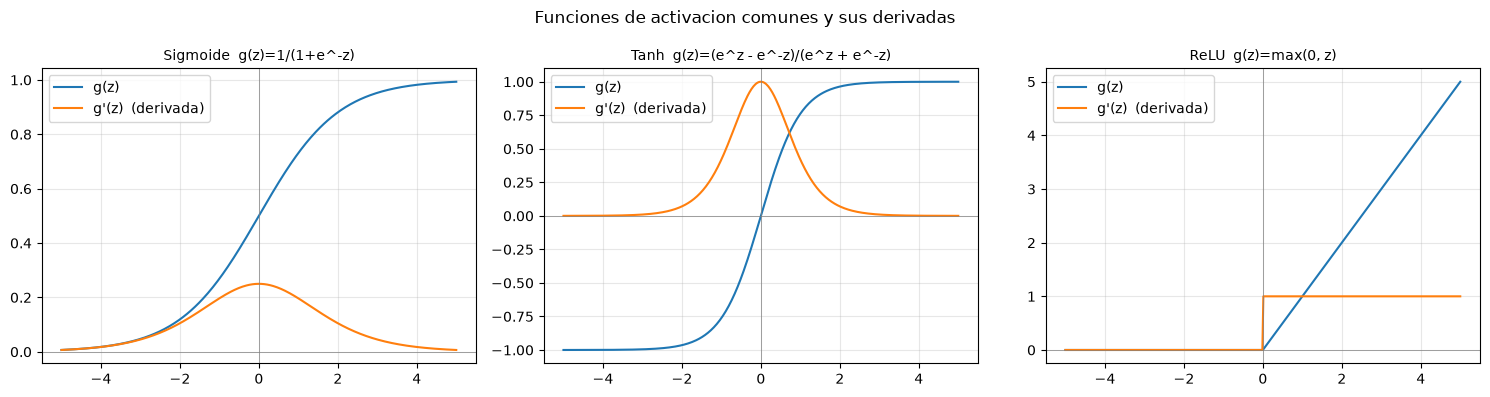

Derivada maxima de la sigmoide: 0.25 -> por eso el gradiente se 'desvanece' en redes profundas


In [4]:
# Grafico comparativo de las funciones de activacion y sus derivadas
import numpy as np, matplotlib.pyplot as plt

z = np.linspace(-5, 5, 400)
sigmoide = 1 / (1 + np.exp(-z));  d_sig  = sigmoide * (1 - sigmoide)
tanh     = np.tanh(z);            d_tanh = 1 - tanh**2
relu     = np.maximum(0, z);      d_relu = (z > 0).astype(float)

funciones = [("Sigmoide  g(z)=1/(1+e^-z)", sigmoide, d_sig),
             ("Tanh  g(z)=(e^z - e^-z)/(e^z + e^-z)", tanh, d_tanh),
             ("ReLU  g(z)=max(0, z)", relu, d_relu)]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, (titulo, g, dg) in zip(ax, funciones):
    a.plot(z, g,  label="g(z)")
    a.plot(z, dg, label="g'(z)  (derivada)")
    a.set_title(titulo, fontsize=10)
    a.axhline(0, lw=.5, c='gray'); a.axvline(0, lw=.5, c='gray')
    a.grid(alpha=.3); a.legend()
plt.suptitle("Funciones de activacion comunes y sus derivadas")
plt.tight_layout(); plt.show()

print("Derivada maxima de la sigmoide:", round(d_sig.max(), 3),
      "-> por eso el gradiente se 'desvanece' en redes profundas")

In [5]:
# SOFTMAX: convierte puntajes crudos (logits) en probabilidades que suman 1
import numpy as np

def softmax(z):
    e = np.exp(z - z.max())      # se resta el maximo por estabilidad numerica
    return e / e.sum()

logits = np.array([1.2, 0.3, 5.1, -2.0, 0.0, 0.7, 1.1, 3.9, 0.2, -0.5])  # salida cruda de los 10 digitos
p = softmax(logits)

for d, prob in enumerate(p):
    print(f"digito {d}: {prob:6.2%} " + "#" * int(prob * 50))
print()
print(f"Suma de probabilidades: {p.sum():.4f}   <- siempre 1")
print(f"Prediccion final (argmax): {p.argmax()}")

digito 0:  1.47% 
digito 1:  0.60% 
digito 2: 72.55% ####################################
digito 3:  0.06% 
digito 4:  0.44% 
digito 5:  0.89% 
digito 6:  1.33% 
digito 7: 21.85% ##########
digito 8:  0.54% 
digito 9:  0.27% 

Suma de probabilidades: 1.0000   <- siempre 1
Prediccion final (argmax): 2


## 3.3 Las activaciones en Scikit-Learn (¡clave para el TP!)

> *"En Scikit-Learn, la función de activación se define mediante el parámetro `activation` en el constructor del modelo. Este parámetro se aplica **exclusivamente a las capas ocultas**."*

```python
MLPClassifier(activation='relu')   # opciones: 'identity', 'logistic', 'tanh', 'relu'
```

**No se puede cambiar manualmente la activación de la capa de salida.** El modelo la asigna solo, según la tarea:

| Modelo | Activación de salida | Cuándo |
|---|---|---|
| `MLPClassifier` | **Sigmoide** | Clasificación **binaria** |
| `MLPClassifier` | **Softmax** | Clasificación **multiclase** (el caso de MNIST) |
| `MLPRegressor` | **Lineal / identidad** | Regresión |

> 🎯 En el TP3 usamos `activation='logistic'`: eso significa **sigmoide en las 50 neuronas ocultas**.
> La capa de salida usa **softmax igual**, porque hay 10 clases y sklearn lo decide solo.

---
# 4. Funciones de Pérdida (*Loss Functions*)

## 4.1 Qué es y para qué sirve

La **función de pérdida** mide **cuánto se equivocó** la red. Es el número que el entrenamiento intenta **minimizar**.

| | Función de **pérdida** | **Métrica** |
|---|---|---|
| Para qué sirve | Guiar el entrenamiento (se deriva) | Informarnos a nosotros |
| ¿Debe ser derivable? | ✅ Sí | ❌ No hace falta |
| Ejemplos | Cross-Entropy, MSE | Accuracy, F1-score |

> 💡 **Por qué no se usa la accuracy como pérdida:** es escalonada (cuenta aciertos), su derivada es 0 casi en todas partes y no le diría a la red *hacia dónde* moverse.

## 4.2 Las dos funciones de pérdida de la unidad

### 🔹 Log-Loss / Cross-Entropy (Entropía Cruzada) → **Clasificación**

$$L = -\frac{1}{N}\sum_{i=1}^{N}\sum_{c=1}^{C} y_{i,c}\,\log(\hat{y}_{i,c})$$

Como $y_{i,c}$ vale 1 solo para la clase verdadera, en la práctica queda $L = -\log(\text{probabilidad que la red le dio a la clase correcta})$.

Castiga muy fuerte estar **seguro y equivocado**: si le da 0,01 a la clase correcta, la pérdida es $-\log(0{,}01)=4{,}6$; si le da 0,99, es apenas $0{,}01$.

### 🔹 Squared Loss / MSE (Error Cuadrático Medio) → **Regresión**

$$L = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2$$

Mide el error cuadrático entre la predicción continua y el valor real.

## 4.3 En Scikit-Learn NO se configura

> *"En Scikit-Learn **no se pasa la función de pérdida como un argumento configurable**. El modelo la selecciona automáticamente según la clase que instancies y el tipo de etiqueta $y$."*

| Clase que instancio | Pérdida que usa |
|---|---|
| `MLPClassifier` | **Log-Loss / Cross-Entropy** |
| `MLPRegressor` | **Squared Loss / MSE** |

Se consulta la pérdida final con **`modelo.loss_`** y su evolución con **`modelo.loss_curve_`**.

> ⚠️ Esto contrasta con Keras/TensorFlow, donde sí se elige explícitamente:
> `model.compile(loss='categorical_crossentropy', optimizer='adam')`.

In [6]:
# CROSS-ENTROPY a mano: por que castiga la confianza equivocada
import numpy as np

print("Probabilidad que la red le dio a la clase CORRECTA  ->  Perdida")
print("-" * 62)
for prob in [0.99, 0.90, 0.70, 0.50, 0.20, 0.05, 0.01]:
    print(f"   {prob:>5.0%}   ->   loss = -log({prob}) = {-np.log(prob):.4f}")

print()
print("Caso multiclase completo (el digito real es el 7):")
y_real = np.array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0])                          # one-hot
y_pred = np.array([.01, .02, .01, .03, .02, .05, .01, .80, .03, .02])      # salida del softmax
loss = -np.sum(y_real * np.log(y_pred))
print(f"  Perdida = -log(0.80) = {loss:.4f}   (solo pesa la probabilidad de la clase verdadera)")

# MSE para regresion
y_v, y_p = np.array([10., 20., 30.]), np.array([12., 18., 33.])
print()
print(f"MSE de regresion: media de (y - y_pred)^2 = {np.mean((y_v - y_p)**2):.4f}")

Probabilidad que la red le dio a la clase CORRECTA  ->  Perdida
--------------------------------------------------------------
     99%   ->   loss = -log(0.99) = 0.0101
     90%   ->   loss = -log(0.9) = 0.1054
     70%   ->   loss = -log(0.7) = 0.3567
     50%   ->   loss = -log(0.5) = 0.6931
     20%   ->   loss = -log(0.2) = 1.6094
      5%   ->   loss = -log(0.05) = 2.9957
      1%   ->   loss = -log(0.01) = 4.6052

Caso multiclase completo (el digito real es el 7):
  Perdida = -log(0.80) = 0.2231   (solo pesa la probabilidad de la clase verdadera)

MSE de regresion: media de (y - y_pred)^2 = 5.6667


---
# 5. Cómo aprende la red: el método `.fit()`

Una sola línea de código —`modelo.fit(X_train, y_train)`— ejecuta un ciclo iterativo que se repite miles de veces:

```
                +---------------------------+
                |                           |
                v                           |
     1. FORWARD PASS          2. LOSS       |
     datos  ->  prediccion    prediccion vs real -> ERROR
                                   |                |
                                   v                |
                          3. BACKPROPAGATION        |
                          error -> actualizar W y b -+

              Optimizacion SGD (Stochastic Gradient Descent)
```

| Paso | Nombre | Qué ocurre |
|---|---|---|
| 1 | **Forward pass** (propagación hacia adelante) | Los datos entran y salen convertidos en una predicción |
| 2 | **Loss calculation** | Se compara la predicción con el valor real → error |
| 3 | **Backpropagation** (retropropagación) | El error viaja hacia atrás y se calcula cuánta "culpa" tiene cada peso (derivadas parciales, regla de la cadena) |
| 4 | **Actualización** | Cada peso se corrige en la dirección opuesta al gradiente |

## 5.1 La regla de actualización (descenso de gradiente)

$$w_{\text{nuevo}} = w_{\text{viejo}} - \eta \cdot \frac{\partial L}{\partial w}$$

donde $\eta$ (*eta*) es la **tasa de aprendizaje** (`learning_rate_init` en sklearn).

| $\eta$ | Consecuencia |
|---|---|
| Muy chica | Aprende lentísimo, puede no converger dentro de `max_iter` |
| Justa | Baja la pérdida de forma suave y estable |
| Muy grande | "Rebota", la pérdida oscila o explota (diverge) |

## 5.2 Batch, mini-batch y época

| Término | Definición |
|---|---|
| **Época** (*epoch*) | Una pasada completa por **todo** el conjunto de entrenamiento |
| **Batch** | El grupo de muestras que se procesa antes de actualizar los pesos |
| **Iteración** | Una actualización de pesos |
| **SGD** (*Stochastic Gradient Descent*) | Actualiza usando mini-lotes al azar → más rápido y ruidoso (el ruido ayuda a escapar de mínimos locales) |

En `MLPClassifier`, **`max_iter` es la cantidad máxima de épocas** cuando el solver es `sgd` o `adam`.

## 5.3 Los tres *solvers* de Scikit-Learn

| `solver` | Cómo funciona | Cuándo usarlo |
|---|---|---|
| `'sgd'` | Descenso de gradiente estocástico clásico | El que pide el TP3; didáctico, sensible al *learning rate* |
| `'adam'` | SGD con tasa de aprendizaje adaptativa por parámetro | **Default y mejor opción** para datasets grandes |
| `'lbfgs'` | Optimizador cuasi-Newton (usa toda la muestra) | Datasets **chicos** (converge muy rápido; por eso lo usamos en el XOR) |

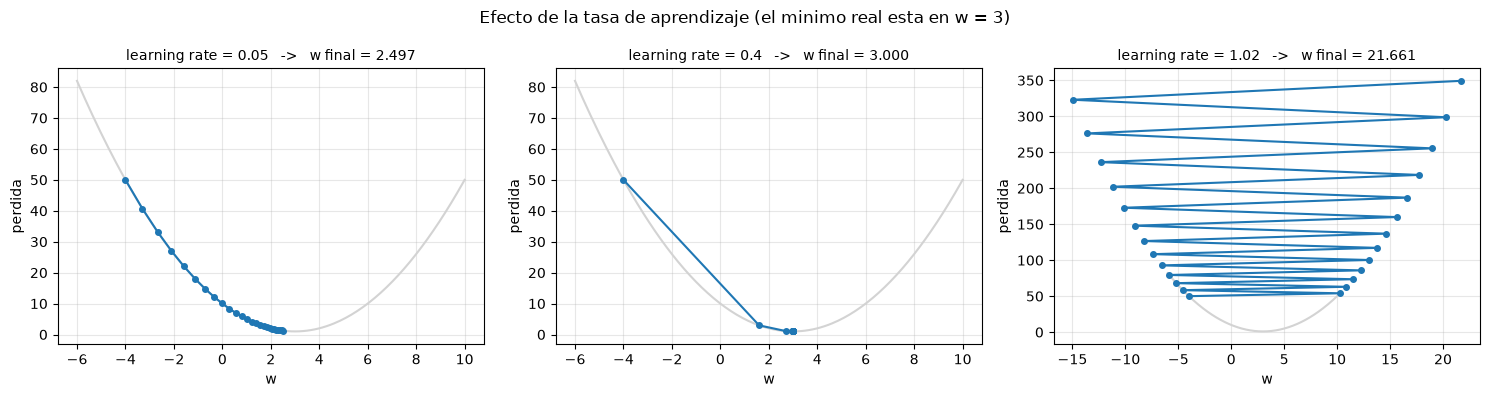

lr chico -> lento pero seguro | lr justo -> converge rapido | lr grande -> diverge


In [7]:
# Descenso de gradiente en 1D: ver el efecto de la tasa de aprendizaje
import numpy as np, matplotlib.pyplot as plt

f      = lambda w: (w - 3)**2 + 1     # "funcion de perdida" de juguete, minimo en w=3
df     = lambda w: 2 * (w - 3)        # su derivada (gradiente)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, lr in zip(ax, [0.05, 0.4, 1.02]):
    w, hist = -4.0, [-4.0]
    for _ in range(25):
        w = w - lr * df(w)            # <-- la regla de actualizacion
        hist.append(w)
    xs = np.linspace(-6, 10, 200)
    a.plot(xs, f(xs), c='lightgray')
    a.plot(hist, [f(h) for h in hist], 'o-', ms=4)
    a.set_title(f"learning rate = {lr}   ->   w final = {w:.3f}", fontsize=10)
    a.grid(alpha=.3); a.set_xlabel("w"); a.set_ylabel("perdida")
plt.suptitle("Efecto de la tasa de aprendizaje (el minimo real esta en w = 3)")
plt.tight_layout(); plt.show()

print("lr chico -> lento pero seguro | lr justo -> converge rapido | lr grande -> diverge")

C:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


solver=sgd   activation=logistic  -> loss_=1.0621  accuracy test=0.7335


solver=adam  activation=relu      -> loss_=0.0201  accuracy test=0.9190


C:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


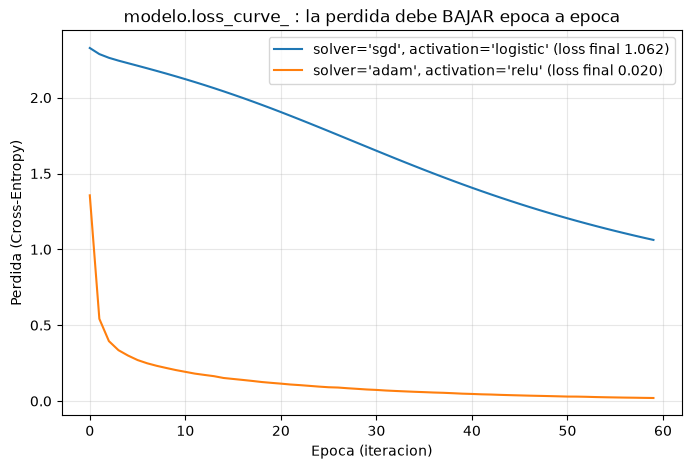

In [8]:
# La curva de perdida: como se ve el aprendizaje epoca a epoca
# (se usa un subconjunto chico de MNIST para que corra rapido)
import numpy as np, matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.neural_network import MLPClassifier

(Xtr, ytr), (Xte, yte) = mnist.load_data()
Xtr = (Xtr[:8000] / 255.0).reshape(8000, -1); ytr = ytr[:8000]
Xte = (Xte[:2000] / 255.0).reshape(2000, -1); yte = yte[:2000]

plt.figure(figsize=(8, 5))
for solver, act in [('sgd', 'logistic'), ('adam', 'relu')]:
    m = MLPClassifier(hidden_layer_sizes=(50,), activation=act, solver=solver,
                      max_iter=60, random_state=42).fit(Xtr, ytr)
    plt.plot(m.loss_curve_, label=f"solver='{solver}', activation='{act}' (loss final {m.loss_:.3f})")
    print(f"solver={solver:5s} activation={act:9s} -> loss_={m.loss_:.4f}  accuracy test={m.score(Xte, yte):.4f}")

plt.xlabel("Epoca (iteracion)"); plt.ylabel("Perdida (Cross-Entropy)")
plt.title("modelo.loss_curve_ : la perdida debe BAJAR epoca a epoca")
plt.legend(); plt.grid(alpha=.3); plt.show()

---
# 6. Hiperparámetros vs. Parámetros

| | **Parámetros** | **Hiperparámetros** |
|---|---|---|
| Quién los fija | **Los aprende el modelo** durante `.fit()` | **Los elegimos nosotros** antes de entrenar |
| Ejemplos | pesos $W$, sesgos $b$ | `hidden_layer_sizes`, `activation`, `solver`, `max_iter` |
| Dónde se ven | `modelo.coefs_`, `modelo.intercepts_` | En el constructor `MLPClassifier(...)` |

## 6.1 Hiperparámetros principales de `MLPClassifier`

| Parámetro | Default | Qué controla |
|---|---|---|
| `hidden_layer_sizes` | `(100,)` | **Topología**: una tupla con las neuronas de cada capa oculta. `(50,)` = 1 capa de 50; `(128, 64)` = 2 capas |
| `activation` | `'relu'` | **No linealidad** de las capas ocultas: `'identity'`, `'logistic'`, `'tanh'`, `'relu'` |
| `solver` | `'adam'` | **Cómo aprende**: `'sgd'`, `'adam'`, `'lbfgs'` |
| `alpha` | `0.0001` | **Regularización L2**: penaliza pesos grandes para evitar sobreajuste |
| `batch_size` | `'auto'` | Tamaño del mini-lote (`min(200, n_muestras)`) |
| `learning_rate_init` | `0.001` | Tasa de aprendizaje inicial $\eta$ |
| `learning_rate` | `'constant'` | Cómo evoluciona $\eta$: `'constant'`, `'invscaling'`, `'adaptive'` |
| `max_iter` | `200` | **Máximo de épocas**. Si no converge antes, aparece `ConvergenceWarning` |
| `tol` | `1e-4` | Mejora mínima para considerar que sigue aprendiendo |
| `n_iter_no_change` | `10` | Épocas sin mejora antes de frenar |
| `early_stopping` | `False` | Separa un 10% de validación y corta cuando deja de mejorar |
| `random_state` | `None` | **Semilla**: hace el resultado reproducible (los pesos se inicializan al azar) |
| `verbose` | `False` | Imprime la pérdida en cada época |

> 🎯 **La línea del TP3, traducida:**
> ```python
> MLPClassifier(hidden_layer_sizes=(50,),   # 1 capa oculta de 50 neuronas
>               activation='logistic',      # sigmoide en la capa oculta
>               solver='sgd',               # descenso de gradiente estocastico
>               max_iter=200,               # hasta 200 epocas
>               random_state=42)            # resultado reproducible
> ```

## 6.2 Atributos disponibles **después** de entrenar

| Atributo | Qué devuelve | En el TP3 |
|---|---|---|
| `n_layers_` | Total de capas (entrada + ocultas + salida) | **3** |
| `n_outputs_` | Neuronas de salida | **10** |
| `coefs_` | **Lista** de matrices de pesos | `coefs_[0]` → (784, 50); `coefs_[1]` → (50, 10) |
| `intercepts_` | Lista de vectores de bias | `(50,)` y `(10,)` |
| `loss_` | Pérdida final alcanzada | un número chico |
| `loss_curve_` | Pérdida en cada época | lista |
| `n_iter_` | Épocas efectivamente corridas | ≤ 200 |
| `classes_` | Etiquetas detectadas | `[0…9]` |

### ⭐ Cómo leer una forma (*shape*) de pesos

`coefs_[0].shape == (784, 50)` se lee: **"784 entradas × 50 neuronas"** → cada una de las 50 neuronas ocultas tiene 784 pesos, uno por píxel.

> 📌 **Comparación con el TP2 (perceptrón simple):** ahí `clf.coef_.shape` era `(10, 784)` → 10 neuronas, cada una con 784 pesos.
> En el MLP hay **dos** matrices porque hay dos conexiones entre capas, y sklearn las guarda como `(entradas, neuronas)`.

---
# 7. Preprocesamiento: normalizar y aplanar

## 7.1 Normalización (÷ 255)

```python
X_train = X_train / 255.0
X_test  = X_test  / 255.0
```

Cada píxel de MNIST es un entero de **0 a 255** (escala de grises: 0 negro, 255 blanco). Al dividir por 255 quedan en **[0, 1]**.

**¿Por qué?**
1. Con entradas grandes, $z = Wx+b$ da valores enormes → la sigmoide **satura** (devuelve 0 o 1) y su derivada se hace 0 → la red deja de aprender.
2. Todas las características quedan en la misma escala → el gradiente es más estable y la convergencia mucho más rápida.

> ⚠️ Es **normalizar**, no cambiar el color: la imagen se ve igual, cambia solo el rango numérico.

## 7.2 Aplanado (*reshape*)

```python
X_train = X_train.reshape(len(X_train), -1)   # (60000, 28, 28) -> (60000, 784)
X_test  = X_test.reshape(len(X_test), -1)     # (10000, 28, 28) -> (10000, 784)
```

> *"El Perceptrón no 've' imágenes cuadradas, solo procesa vectores numéricos."*

Un MLP es una **capa densa**: espera una tabla de 2 dimensiones `(n_muestras, n_características)`. La imagen 2D de 28×28 se convierte en un vector 1D de $28 \times 28 = 784$ elementos.

- El `-1` significa *"calculá vos esta dimensión"* → NumPy deduce 784.
- El aplanado **no pierde información** de valores, pero sí **pierde la noción de vecindad espacial** (qué píxel está al lado de cuál). Esa es exactamente la limitación que después resuelven las **redes convolucionales (CNN)**.

ANTES  -> forma: (28, 28) | tipo: uint8 | rango: 0 - 255
NORMALIZADA -> rango: 0.0 - 1.0
APLANADA -> forma: (784,) ( 28 x 28 = 784 )


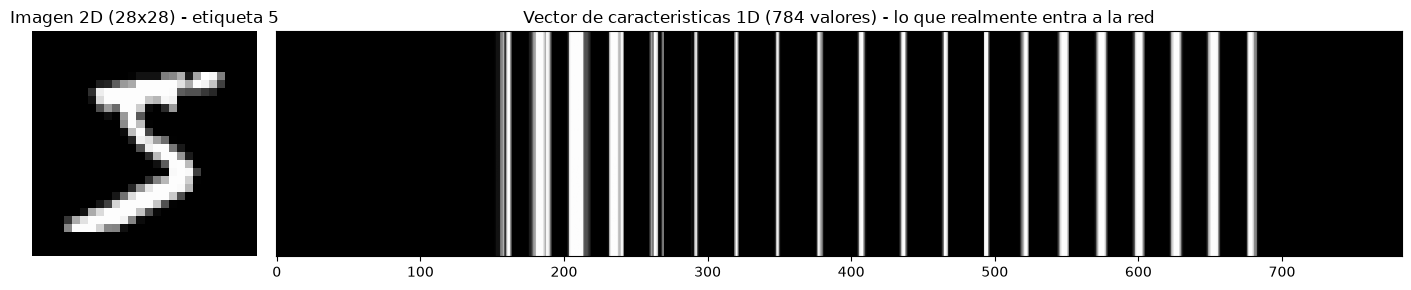

In [9]:
# Demostracion visual del preprocesamiento
import numpy as np, matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(Xtr, ytr), _ = mnist.load_data()
img = Xtr[0]

print("ANTES  -> forma:", img.shape, "| tipo:", img.dtype, "| rango:", img.min(), "-", img.max())
img_norm = img / 255.0
print("NORMALIZADA -> rango:", img_norm.min(), "-", round(img_norm.max(), 2))
vector = img_norm.reshape(-1)
print("APLANADA -> forma:", vector.shape, "( 28 x 28 =", 28*28, ")")

fig, ax = plt.subplots(1, 2, figsize=(14, 3),
                       gridspec_kw={'width_ratios': [1, 5]})
ax[0].imshow(img, cmap='gray'); ax[0].set_title(f"Imagen 2D (28x28) - etiqueta {ytr[0]}"); ax[0].axis('off')
ax[1].imshow(vector.reshape(1, -1), cmap='gray', aspect='auto')
ax[1].set_title("Vector de caracteristicas 1D (784 valores) - lo que realmente entra a la red")
ax[1].set_yticks([])
plt.tight_layout(); plt.show()

---
# 8. Evaluación del modelo

## 8.1 La matriz de confusión

Para una clase concreta (por ejemplo, "es un 7"):

| | Predijo POSITIVO | Predijo NEGATIVO |
|---|---|---|
| **Es POSITIVO** | **VP** (verdadero positivo) ✅ | **FN** (falso negativo) ❌ |
| **Es NEGATIVO** | **FP** (falso positivo) ❌ | **VN** (verdadero negativo) ✅ |

## 8.2 Las métricas

$$\text{Accuracy} = \frac{VP+VN}{VP+VN+FP+FN} \qquad \text{(porcentaje de aciertos totales)}$$

$$\text{Precisión} = \frac{VP}{VP+FP} \qquad \text{de todo lo que dije que era 7, ¿cuánto era 7 de verdad?}$$

$$\text{Recall (exhaustividad)} = \frac{VP}{VP+FN} \qquad \text{de todos los 7 que había, ¿cuántos encontré?}$$

$$F_1 = 2\cdot\frac{\text{Precisión}\cdot\text{Recall}}{\text{Precisión}+\text{Recall}} \qquad \text{(media armónica)}$$

## 8.3 ⭐ Por qué F1 y no accuracy

El **F1-score es la media armónica entre precisión y recall**. La media armónica, a diferencia del promedio común, **se desploma si una de las dos es baja**: obliga a que *ambas* sean buenas.

> 🧨 **El ejemplo clásico:** un dataset con 99% de sanos y 1% de enfermos. Un modelo que dice "sano" siempre tiene **99% de accuracy** y es completamente inútil (recall = 0 → F1 = 0).
> Por eso el F1 es **un indicador robusto y balanceado**, ideal para **clases desbalanceadas**.

## 8.4 El parámetro `average`

Como MNIST tiene 10 clases, hay un F1 por clase. `average` dice cómo combinarlos:

| `average` | Cómo combina | Cuándo |
|---|---|---|
| `'macro'` | Promedio simple de los 10 F1 | Todas las clases importan igual |
| `'weighted'` | Promedio **ponderado por la cantidad de muestras** de cada clase | **El que usa el TP3**; tiene en cuenta el desbalance |
| `'micro'` | Cuenta global de VP/FP/FN | Equivale a la accuracy en multiclase |
| `None` | Devuelve el array con los 10 valores | Para ver clase por clase |

```python
f1 = f1_score(y_test, y_pred, average="weighted")
```

In [10]:
# Precision, recall y F1 calculados A MANO y verificados con sklearn
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

y_real = np.array([1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0])
y_pred = np.array([1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0])

VP = ((y_real==1) & (y_pred==1)).sum()
FP = ((y_real==0) & (y_pred==1)).sum()
FN = ((y_real==1) & (y_pred==0)).sum()
VN = ((y_real==0) & (y_pred==0)).sum()
print(f"VP={VP}  FP={FP}  FN={FN}  VN={VN}")

precision = VP / (VP + FP)
recall    = VP / (VP + FN)
f1        = 2 * (precision * recall) / (precision + recall)
accuracy  = (VP + VN) / len(y_real)

print(f"Accuracy  = (VP+VN)/total = {accuracy:.4f}")
print(f"Precision = VP/(VP+FP)    = {precision:.4f}")
print(f"Recall    = VP/(VP+FN)    = {recall:.4f}")
print(f"F1        = media armonica= {f1:.4f}")
print()
print("Verificacion con sklearn:", round(precision_score(y_real, y_pred), 4),
      round(recall_score(y_real, y_pred), 4), round(f1_score(y_real, y_pred), 4))

print()
print("### Por que F1 y no accuracy: el modelo 'todo negativo' ###")
y_des_real = np.array([0]*99 + [1])     # 99 sanos, 1 enfermo
y_des_pred = np.array([0]*100)          # el modelo dice SIEMPRE 'sano'
print("Accuracy:", (y_des_real == y_des_pred).mean(), " <- parece excelente")
print("F1-score:", f1_score(y_des_real, y_des_pred, zero_division=0), " <- revela que es inutil")

VP=3  FP=1  FN=3  VN=13
Accuracy  = (VP+VN)/total = 0.8000
Precision = VP/(VP+FP)    = 0.7500
Recall    = VP/(VP+FN)    = 0.5000
F1        = media armonica= 0.6000

Verificacion con sklearn: 0.75 0.5 0.6

### Por que F1 y no accuracy: el modelo 'todo negativo' ###
Accuracy: 0.99  <- parece excelente
F1-score: 0.0  <- revela que es inutil


              precision    recall  f1-score   support

           0     0.9569    0.9745    0.9656       980
           1     0.9772    0.9815    0.9793      1135
           2     0.9365    0.9283    0.9324      1032
           3     0.9174    0.9455    0.9313      1010
           4     0.9267    0.9521    0.9392       982
           5     0.9452    0.9081    0.9262       892
           6     0.9498    0.9489    0.9493       958
           7     0.9436    0.9446    0.9441      1028
           8     0.9354    0.9066    0.9208       974
           9     0.9291    0.9227    0.9259      1009

    accuracy                         0.9421     10000
   macro avg     0.9418    0.9413    0.9414     10000
weighted avg     0.9422    0.9421    0.9420     10000

F1 macro   : 0.9414
F1 weighted: 0.942
F1 micro   : 0.9421  (= accuracy)


C:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (40) reached and the optimization hasn't converged yet.
  warnings.warn(


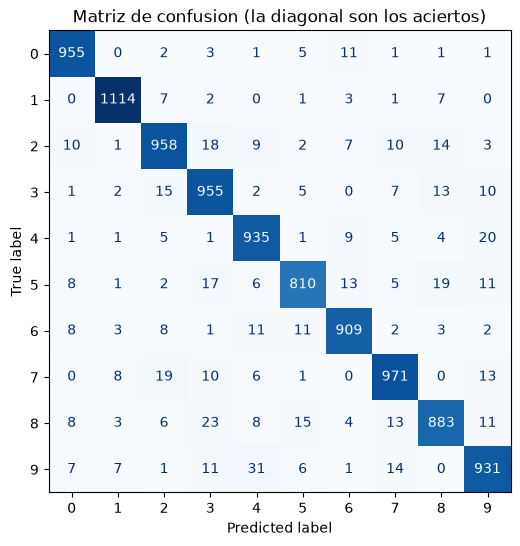

In [11]:
# Informe de clasificacion completo sobre MNIST (subconjunto rapido)
import numpy as np, matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay

(Xtr, ytr), (Xte, yte) = mnist.load_data()
Xtr = (Xtr[:10000] / 255.0).reshape(10000, -1); ytr = ytr[:10000]
Xte = (Xte / 255.0).reshape(len(Xte), -1)

m = MLPClassifier(hidden_layer_sizes=(50,), activation='relu', solver='adam',
                  max_iter=40, random_state=42).fit(Xtr, ytr)
yp = m.predict(Xte)

print(classification_report(yte, yp, digits=4))
print("F1 macro   :", round(f1_score(yte, yp, average='macro'), 4))
print("F1 weighted:", round(f1_score(yte, yp, average='weighted'), 4))
print("F1 micro   :", round(f1_score(yte, yp, average='micro'), 4), " (= accuracy)")

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix(yte, yp)).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Matriz de confusion (la diagonal son los aciertos)")
plt.show()

---
# 9. Sobreajuste, subajuste y regularización

| | **Underfitting** (subajuste) | **Ajuste correcto** | **Overfitting** (sobreajuste) |
|---|---|---|---|
| Error en entrenamiento | Alto | Bajo | **Muy bajo** |
| Error en test | Alto | Bajo | **Alto** |
| Qué pasó | El modelo es **demasiado simple** | 👍 | El modelo **memorizó** el entrenamiento, incluido el ruido |
| Cómo se arregla | Más neuronas/capas, más épocas | — | Menos neuronas, más `alpha`, `early_stopping`, más datos |

**Herramientas de Scikit-Learn contra el sobreajuste:**

| Herramienta | Qué hace |
|---|---|
| `alpha` (L2) | Penaliza los pesos grandes: fuerza soluciones más suaves |
| `early_stopping=True` | Reserva un 10% para validación y frena cuando deja de mejorar |
| `n_iter_no_change` | Cuántas épocas de paciencia antes de frenar |
| Reducir `hidden_layer_sizes` | Menos capacidad = menos posibilidad de memorizar |

> 🔑 **Regla de oro:** el modelo se **elige y ajusta** mirando entrenamiento/validación, pero se **juzga** con el conjunto de **test**, que el modelo nunca vio (`predict(X_test)`).

---
# 10. Errores comunes (checklist antes de entregar)

- ❌ **Olvidarse el `reshape`** → `ValueError: Found array with dim 3. Estimator expected <= 2.`
- ❌ **Normalizar después de aplanar sobre `X_test` y olvidarse de `X_train`** (o viceversa): el preprocesamiento tiene que ser **idéntico** en ambos.
- ❌ **Normalizar dos veces** (correr la celda de nuevo divide otra vez por 255).
- ❌ **Confundir `coefs_[0]` con `coef_`**: el MLP usa `coefs_` (lista, plural), el perceptrón simple usaba `coef_`.
- ⚠️ **`ConvergenceWarning`**: no es un error; avisa que llegó a `max_iter` sin converger. Se soluciona subiendo `max_iter` o cambiando a `solver='adam'`.
- ❌ **Evaluar con `X_train`**: da un número inflado y no dice nada sobre la capacidad de generalizar.
- ❌ **Olvidar `random_state`**: los resultados cambian en cada corrida y no se pueden reproducir.

---
# 11. Glosario

| Término | Definición breve |
|---|---|
| **MLP** | *Multi-Layer Perceptron*: red de capas densas con al menos una capa oculta |
| **Capa densa / fully connected** | Cada neurona se conecta con **todas** las de la capa anterior |
| **Forward propagation** | Recorrido de los datos desde la entrada hasta la predicción |
| **Backpropagation** | Propagación del error hacia atrás para calcular los gradientes |
| **Gradiente** | Derivada de la pérdida respecto de un peso: indica en qué dirección crece el error |
| **Learning rate ($\eta$)** | Tamaño del paso en cada actualización de pesos |
| **Época** | Una pasada completa por todo el conjunto de entrenamiento |
| **Función de activación** | Transformación no lineal que se aplica a $z$ |
| **Función de pérdida** | Número que mide el error y que el entrenamiento minimiza |
| **Cross-Entropy** | Pérdida para clasificación (la que usa `MLPClassifier`) |
| **MSE** | Pérdida para regresión (la que usa `MLPRegressor`) |
| **Softmax** | Convierte puntajes en probabilidades que suman 1 |
| **Logit** | Puntaje crudo de la capa de salida, antes del softmax |
| **One-hot** | Representación de una etiqueta como vector de ceros con un 1 |
| **Vanishing gradient** | Gradientes que se vuelven casi 0 y frenan el aprendizaje |
| **Overfitting** | Memorizar el entrenamiento y fallar en datos nuevos |
| **Regularización (alpha)** | Penalización que evita pesos demasiado grandes |
| **Hiperparámetro** | Valor que elegimos nosotros antes de entrenar |

---
# 12. Chuleta: el TP3 en 15 líneas

```python
from tensorflow.keras.datasets import mnist
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score
import joblib

(X_train, y_train), (X_test, y_test) = mnist.load_data()   # (60000,28,28) / (10000,28,28)

X_train, X_test = X_train/255.0, X_test/255.0              # normalizar -> [0,1]
X_train = X_train.reshape(len(X_train), -1)                # aplanar -> (60000,784)
X_test  = X_test.reshape(len(X_test), -1)                  #           (10000,784)

modelo = MLPClassifier(hidden_layer_sizes=(50,), activation='logistic',
                       solver='sgd', max_iter=200, random_state=42)
modelo.fit(X_train, y_train)                               # forward + loss + backprop

y_pred = modelo.predict(X_test)
print(f1_score(y_test, y_pred, average="weighted"))
joblib.dump(modelo, 'modelo_mnist.pkl')
```

### Los números que hay que saber de memoria

| Dato | Valor |
|---|---|
| Forma original de `X_train` | **(60000, 28, 28)** |
| Forma original de `X_test` | **(10000, 28, 28)** |
| Forma después del `reshape` | **(60000, 784)** y **(10000, 784)** |
| Rango de píxeles antes / después | 0–255 → 0–1 |
| `modelo.n_layers_` | **3** |
| `modelo.n_outputs_` | **10** |
| `modelo.coefs_[0].shape` | **(784, 50)** |
| `modelo.coefs_[1].shape` | **(50, 10)** |
| Parámetros totales | **39.760** |
| Pérdida que usa `MLPClassifier` | **Cross-Entropy (Log-Loss)** |
| Activación de salida (10 clases) | **Softmax (automática)** |

---
# 13. Autoevaluación

Respondé primero y después abrí la celda siguiente con las soluciones.

1. ¿Por qué un MLP sin funciones de activación no lineales es equivalente a una sola neurona?
2. ¿Qué diferencia hay entre una función de pérdida y una métrica?
3. En `MLPClassifier(activation='tanh')`, ¿a qué capas se aplica esa tanh?
4. ¿Qué función de activación usa la capa de salida en MNIST y quién la elige?
5. ¿Cuántos parámetros entrenables tiene una red 784 → 128 → 64 → 10?
6. ¿Qué significa `coefs_[0].shape == (784, 50)`?
7. ¿Por qué se divide por 255 antes de entrenar?
8. ¿Qué información se pierde al aplanar la imagen?
9. Un modelo tiene accuracy 0,97 y F1-macro 0,42. ¿Qué está pasando?
10. ¿Qué hace `random_state=42` y por qué importa?
11. ¿Cuál es la diferencia entre `solver='sgd'` y `solver='adam'`?
12. ¿Qué indica un `ConvergenceWarning` y cómo se soluciona?

### ✅ Respuestas

1. Porque la composición de funciones lineales es lineal: $W_2(W_1x+b_1)+b_2 = W'x+b'$. Sin no linealidad, agregar capas no agrega poder expresivo.
2. La **pérdida** guía el entrenamiento (tiene que ser derivable para calcular gradientes); la **métrica** es para interpretación humana y no necesita ser derivable. En `MLPClassifier`, pérdida = Cross-Entropy, métrica = F1/accuracy.
3. **Solo a las capas ocultas.** La de salida la define sklearn automáticamente.
4. **Softmax**, porque es clasificación multiclase (10 clases), y **la elige sklearn solo**: no se puede configurar.
5. $(784\times128+128) + (128\times64+64) + (64\times10+10) = 100.480 + 8.256 + 650 = $ **109.386**.
6. Que la matriz de pesos entre la entrada y la capa oculta tiene **784 filas (una por píxel de entrada) y 50 columnas (una por neurona oculta)**: cada neurona oculta tiene 784 pesos.
7. Para llevar los píxeles al rango [0,1]: evita que $z$ sea enorme y sature la sigmoide (gradiente ≈ 0), y hace la convergencia más rápida y estable.
8. La **estructura espacial / vecindad** entre píxeles. El MLP trata cada píxel como una característica independiente; recuperar esa información es lo que hacen las CNN.
9. Hay **clases muy desbalanceadas** y el modelo acierta la clase mayoritaria pero falla en las minoritarias (recall bajo en varias clases). La accuracy engaña; el F1-macro lo revela.
10. Fija la **semilla** de la inicialización aleatoria de pesos y del barajado de los mini-lotes. Sirve para que el resultado sea **reproducible** entre corridas.
11. `sgd` es el descenso de gradiente estocástico clásico con tasa de aprendizaje fija; `adam` adapta la tasa de aprendizaje por parámetro, converge más rápido y es el default para datasets grandes.
12. Que el optimizador llegó a `max_iter` sin que la pérdida dejara de mejorar (no convergió). Se soluciona **aumentando `max_iter`**, cambiando a `solver='adam'` o ajustando el *learning rate*. **No es un error**, el modelo igual quedó entrenado.

---
### Fuentes de esta guía
- `3.1-Funciones_de_Activacion_y_Perdida._MLP.pdf` (teoría de la Unidad 3)
- `calculo_de_hiper_parametros.docx.pdf` (conteo de parámetros)
- `Trabajo_Practico_3_MLP_.ipynb` (consigna) y `2-El_Perceptron.pdf` (Unidad 2, repaso)
- Documentación oficial de Scikit-Learn: `sklearn.neural_network.MLPClassifier`, `sklearn.metrics.f1_score`